# Module 13, Recitation 1: Multimodal Machine Learning for Pleural Effusion Prediction

This notebook demonstrates a multimodal machine learning pipeline for predicting **pleural effusion** using different types of patient data from the **MIMIC** dataset.

---

## 🧠 What is Multimodality?

**Multimodal learning** involves combining information from different sources (modalities), like:
- 📄 **Text**: Clinical notes
- 🧪 **Tabular data**: Demographics
- 📷 **Medical images**: Chest X-rays
- 📊 **Time series**: Lab measurements, events over time

Fusion of these modalities often yields better predictive performance because each captures unique aspects of the patient's condition.

---

## 🏥 What is MIMIC?

[MIMIC-III/MIMIC-IV](https://mimic.mit.edu/) is a publicly available, de-identified dataset from ICU patients at the Beth Israel Deaconess Medical Center. It includes:
- Demographics
- Clinical notes
- Imaging data
- Labs, vitals, medications

⚠️ **Note:** This notebook avoids displaying any raw patient data to maintain privacy.

---

## ✅ Objective

The goal is to predict the existence of pleural effusion in patient's lungs, for patients that are admitted to the ICU. Each row corresponds to a certain patient. We aim to train separate XGBoost models on each modality and one **combined fusion model**, evaluating them using the AUC metric.

Let's begin!


In [ ]:
import pandas as pd
import numpy as np
import os
import numpy as np
import torch
import torch.nn.functional as F
import cv2
import pandas as pd
from tqdm import tqdm
import torchvision
import numpy as np
import pandas as pd
import torch
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

In [ ]:
!pip install torchxrayvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 759.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import torchxrayvision as xrv

# Step 1: Loading the data

Here, we are loading the data that we have already preprocessed. For data agreement purposes, we cannot display the raw data. However, we can briefly explore some of the information they contain.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Tabular
df_tab = pd.read_csv("/content/drive/My Drive/final_tab_data.csv")

# Time series
df_ts = pd.read_csv("/content/drive/My Drive/final_ts_data.csv")

# Notes
df_notes = pd.read_csv("/content/drive/My Drive/final_notes_data.csv")

# Images
df_img = pd.read_csv("/content/drive/My Drive/final_img_data.csv")
images = np.load("/content/drive/My Drive/final_images.npz")

## Tabular

Apart from some identifiers, the tabular dataframe contains information about different demographics. These are static and do not change overtime for each patient. The '_int' columns correspond to encoded information about the corresponding features.

The last column, Pleural Effusion, is actually our target column that we eventually want to predict.

In [ ]:
print(df_tab.shape[0])

9559


In [ ]:
print(df_tab.columns)

Index(['subject_id', 'hadm_id', 'anchor_age', 'gender', 'ethnicity',
       'marital_status', 'language', 'insurance', 'gender_int',
       'ethnicity_int', 'marital_status_int', 'language_int', 'insurance_int',
       'identifier', 'Pleural Effusion'],
      dtype='object')


## Time series

We can see examples of different measurements that change over time, like lab values.

In [ ]:
print(df_ts['label'].unique())

['Heart Rate' 'Respiratory Rate' 'O2 saturation pulseoxymetry'
 'GCS - Eye Opening' 'GCS - Verbal Response' 'GCS - Motor Response'
 'Non Invasive Blood Pressure systolic'
 'Non Invasive Blood Pressure diastolic'
 'Non Invasive Blood Pressure mean' 'Glucose' 'Hemoglobin' 'Hematocrit'
 'MCH' 'MCHC' 'MCV' 'Platelet Count' 'RDW' 'Red Blood Cells'
 'White Blood Cells' 'Anion Gap' 'Bicarbonate' 'Chloride' 'Creatinine'
 'Potassium' 'Sodium' 'Urea Nitrogen' 'Magnesium' 'Calcium, Total'
 'Phosphate' 'PICC Line' 'Neutrophils' 'Vancomycin' 'Chest Tube Removed'
 'Bronchoscopy' 'Foley Catheter' 'Intubation' 'EEG' 'Dialysis Catheter'
 'Dialysis - CRRT' 'Peritoneal Dialysis' 'Hemodialysis']


## Notes

We can also explore the different types of notes we have available. There are echocardiogram notes, radiology and ECG notes.

In [ ]:
print(df_notes['note_category'].unique())

['Echo' 'Radiology' 'ECG']


## Images

For images, we have a dataframe, df_img, containing the image ids we want to focus on. The actual images are located in the "images" dictionary, whose keys are the image ids.

# Step 2: Extracting embeddings

The next step is to extract embeddings from the different modalities.

## Tabular

In [ ]:
def get_tab_embeddings(df_tab):
  # Inputs:
  #   df_tab -> Dataframe with tabular information for all patients
  #
  # Outputs:
  #   base_embeddings -> Core base tabular embeddings

  # Retrieve dt and get embeddings
  demo_embeddings =  df_tab[['identifier', 'anchor_age', 'gender_int', 'ethnicity_int',
                              'marital_status_int', 'language_int', 'insurance_int', 'Pleural Effusion']]


  return demo_embeddings

In [ ]:
# Tabular Embeddings extraction
tab_embeddings = get_tab_embeddings(df_tab)

It is very easy to extract the tabular embeddings; we only keep the encoded columns that correspond to the demographics. We also keep the final target column to use it later.

## Time Series
For each physiological signal (like heart rate, blood pressure, etc.), we extract the following summary statistics to capture its behavior over time:

- max: The maximum value in the time series.

- min: The minimum value in the time series.

- mean: The average value across all time points.

- variance: The variability or spread of the values.

- meandiff: The average of the differences between consecutive values, capturing the overall drift.

- maxdiff: The largest absolute jump between two consecutive values — helps detect sharp transitions or anomalies.

- meanabsdiff: The average of the absolute differences between consecutive values, reflecting signal volatility.

- sumabsdiff: The total variation over time (sum of all absolute differences).

- diff: The net change in value between the last and the first time point.

- n_peaks: The number of local peaks (using scipy.signal.find_peaks) — helps assess oscillations.

- trend: The slope of a best-fit line through the values — a positive trend indicates an increasing pattern, and vice versa.

In [ ]:
# List of events we want to keep
event_list = ['Glucose', 'Potassium', 'Sodium', 'Chloride', 'Creatinine',
                      'Urea Nitrogen', 'Bicarbonate', 'Anion Gap', 'Hemoglobin', 'Hematocrit',
                      'Magnesium', 'Platelet Count', 'Phosphate', 'White Blood Cells',
                      'Calcium, Total', 'MCH', 'Red Blood Cells', 'MCHC', 'MCV', 'RDW',
                      'Platelet Count', 'Neutrophils', 'Vancomycin', 'Heart Rate', 'Non Invasive Blood Pressure systolic',
                      'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure mean',
                      'Respiratory Rate', 'O2 saturation pulseoxymetry',
                      'GCS - Verbal Response', 'GCS - Eye Opening', 'GCS - Motor Response',
                       'Foley Catheter', 'PICC Line', 'Intubation', 'Peritoneal Dialysis',
                       'Bronchoscopy', 'EEG', 'Dialysis - CRRT', 'Dialysis Catheter',
                       'Chest Tube Removed', 'Hemodialysis']

In [ ]:
def get_ts_embeddings(df, event_list, name='ts', embed=True, fillna=None) -> pd.DataFrame:
    """
    Generates statistical feature embeddings from time series events.

    Args:
        df (pd.DataFrame): Input data with ['identifier', 'label', 'valuenum', 'charttime']
        event_list (list): List of labels to include
        name (str): Prefix for embedding column
        embed (bool): Whether to return as torch tensor
        fillna (float or None): Value to fill missing features; use None to leave NaNs

    Returns:
        pd.DataFrame: DataFrame indexed by 'identifier' with one column f"{name}_emb"
    """

    df = df[df.label.isin(event_list)].copy()
    df = df.sort_values('charttime')

    def n_peaks(x):
        peaks, _ = find_peaks(x)
        return len(peaks)

    def trend(x):
        return np.polyfit(np.arange(len(x)), x, deg=1)[0] if len(x) > 1 else 0

    agg_dict = {
        'max': lambda x: x.max(),
        'min': lambda x: x.min(),
        'mean': lambda x: x.mean(),
        'variance': lambda x: x.var(skipna=True),
        'meandiff': lambda x: x.diff().mean(),
        'meanabsdiff': lambda x: x.diff().abs().mean(),
        'maxdiff': lambda x: x.diff().abs().max(),
        'sumabsdiff': lambda x: x.diff().abs().sum(),
        'diff': lambda x: x.iloc[-1] - x.iloc[0],
        'n_peaks': n_peaks,
        'trend': trend,
    }

    # Group and aggregate
    dfg = df.groupby(['identifier', 'label'])['valuenum'].agg(**agg_dict).reset_index()

    # Pivot to wide format
    dfg = dfg.pivot(index='identifier', columns='label')
    dfg.columns = [f"{stat}_{label}" for stat, label in dfg.columns]

    if fillna is not None:
        dfg = dfg.fillna(fillna)

    # Convert to torch tensors per row
    if embed:
        dfg[f'{name}_emb'] = dfg.apply(lambda row: torch.tensor(row.values, dtype=torch.float32), axis=1)
        dfg = dfg[[f'{name}_emb']]
    dfg = dfg.reset_index()

    return dfg


In [ ]:
ts_embeddings = get_ts_embeddings(df_ts, event_list, embed=False, fillna=0)

After performing the extraction, we end up with a dataframe, where each row corresponds to a specific identifier and contains all the extracted statistics for each of the events in the events list we specified.

## Notes

This code extracts numerical embeddings from clinical notes using the pretrained ClinicalBERT model. Since BERT has a maximum input length (512 tokens), each note is split into smaller overlapping chunks. Each chunk is tokenized, padded, and passed through the model in batches.

From each chunk, we extract the embedding of the [CLS] token, which captures its overall meaning. We group the resulting embeddings by note, so at the end, each clinical note is represented as a list of embeddings—one per chunk—which can be used in downstream machine learning models. We then average the embeddings that correspond to each note, and also across notes, to extract a single 768-dimensional embedding that summarizes all the note information for each patient.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# Load model and tokenizer
def load_clinicalbert(model_name='emilyalsentzer/Bio_ClinicalBERT', device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    return tokenizer, model, device

# Split long texts into chunks of max_length
class ChunkDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=512):
        self.chunks = []
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id

        for text_idx, text in enumerate(texts):
            tokens = tokenizer(text, return_tensors='pt', truncation=False)['input_ids'][0][1:-1]  # Remove CLS/SEP
            chunk_size = max_length - 2
            for i in range(0, len(tokens), chunk_size):
                chunk = tokens[i:i + chunk_size]
                chunk_ids = torch.cat([torch.tensor([cls_id]), chunk, torch.tensor([sep_id])])
                attention = torch.ones_like(chunk_ids)
                self.chunks.append((chunk_ids, attention, text_idx))

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        return self.chunks[idx]

# Pad input_ids and attention_mask to same length
class TextCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch):
        input_ids = [item[0] for item in batch]
        attention_mask = [item[1] for item in batch]
        text_indices = [item[2] for item in batch]

        padded = self.tokenizer.pad(
            {'input_ids': input_ids, 'attention_mask': attention_mask},
            return_tensors='pt'
        )
        padded['text_indices'] = torch.tensor(text_indices)
        return padded

# Main function to extract embeddings
def extract_clinicalbert_embeddings(texts, batch_size=128, aggregation='average'):
    tokenizer, model, device = load_clinicalbert()
    dataset = ChunkDataset(texts, tokenizer)
    dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=TextCollator(tokenizer))

    embeddings_by_text = [[] for _ in texts]

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            text_indices = batch['text_indices']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token

            for emb, idx in zip(cls_embeddings, text_indices):
                embeddings_by_text[idx.item()].append(emb.cpu())

    # Aggregate each text's chunks
    final_embeddings = []
    for chunks in embeddings_by_text:
        final_embeddings.append(torch.stack(chunks))  # return all chunks

    return final_embeddings  # list of torch.Tensor (shape [768] or [n_chunks, 768])


In [ ]:
import pandas as pd
import torch

def average_tensors(tensor_list):
    return torch.stack(tensor_list).mean(dim=0)

def first_tensor(tensor_list):
    return tensor_list[0]

def get_notes_embeddings(df, id_cols, aggregation='average', batch_size=16):
    """
    Generate embeddings from clinical notes using ClinicalBERT.

    Args:
        df (pd.DataFrame): DataFrame with at least a 'text' column and some ID columns
        id_cols (list of str): Column names to group by (e.g., ['subject_id', 'hadm_id'])
        aggregation (str): Aggregation method for multiple chunks ('average' or 'first')
        batch_size (int): Batch size for embedding extraction

    Returns:
        pd.DataFrame: A DataFrame with one row per ID group and a single embedding per row
    """
    from transformers import AutoTokenizer, AutoModel  # import inside to avoid global dependency
    texts = df['text'].tolist()

    # Extract embeddings (one or more per note, depending on chunking)
    embeddings = extract_clinicalbert_embeddings(texts, batch_size=batch_size)

    # Attach embeddings to the original df
    df = df.copy()
    df['embedding'] = embeddings
    df = df.explode('embedding')

    # Aggregate by id_cols
    if aggregation == 'average':
        agg_func = average_tensors
    elif aggregation == 'first':
        agg_func = first_tensor
    else:
        raise ValueError(f"Unknown aggregation method: {aggregation}")

    tuples = [(idx, agg_func(group['embedding'].tolist())) for idx, group in df.groupby(id_cols)]
    output_df = pd.DataFrame(tuples, columns=id_cols + ['notes_emb'])

    # Optional: set ID columns as index
    return output_df.set_index(id_cols)


In [ ]:
notes_embeddings = get_notes_embeddings(df_notes, ['identifier'], batch_size = 128)

100%|██████████| 1614/1614 [35:03<00:00,  1.30s/it]


In [ ]:
notes_embeddings = notes_embeddings.reset_index()

In [ ]:
# Expand to multiple columns
emb_matrix = notes_embeddings['notes_emb'].apply(lambda x: x.numpy() if hasattr(x, 'numpy') else x).to_list()
emb_df = pd.DataFrame(emb_matrix, columns=[f"notes_emb_{i}" for i in range(len(emb_matrix[0]))])

# Combine with original df (drop old _emb column)
notes_embeddings = pd.concat([notes_embeddings.drop(columns=['notes_emb']).reset_index(drop=True),
                         emb_df.reset_index(drop=True)], axis=1)


After this process, we end up with a dataframe that has 768 columns, each of them corresponds to a dimension of the resulting embeddings.

## Images

This code extracts visual embeddings from chest X-ray images using a pretrained DenseNet model provided by TorchXRayVision. Each image is preprocessed—converted to grayscale, resized, and normalized—before being passed through the model in batches. For each image, the model returns both prediction logits and intermediate deep features, which are combined into a single embedding. These embeddings are then stored in a DataFrame and optionally aggregated per patient or study using one of several strategies: averaging all embeddings, keeping only the first, or concatenating the first with the average. This results in a compact and meaningful representation of chest X-ray information for downstream machine learning tasks.

In this specific example, we decided to concatenate the first with the average embedding.

In [ ]:
# -------------------------
# Basic tensor aggregation
# -------------------------
def average_tensors(tensor_list):
    return torch.stack(tensor_list).mean(dim=0)

def first_tensor(tensor_list):
    return tensor_list[0]

def first_avg_agg(tensor_list):
    """
    HAIM_IMG_AGG: Concatenates first tensor with mean of all tensors.
    """
    tmp = torch.stack(tensor_list)
    return torch.hstack((tmp[0, :], tmp.mean(dim=0)))


# -------------------------
# Main embedding extraction
# -------------------------
def get_chestxray_embeddings(
    images,  # List of np.ndarray images
    model_weights="densenet121-res224-chex",
    batch_size=16,
    device=None,
    finetune=False
):
    """
    Extracts DenseNet-based embeddings and prediction logits for chest X-rays.

    Args:
        images (list): List of images (np.ndarray, 2D or 3D).
        model_weights (str): TorchXRayVision model weights.
        batch_size (int): Batch size for processing.
        device (str): 'cuda' or 'cpu'.
        finetune (bool): Whether to allow gradients (False = inference mode).

    Returns:
        list of torch.Tensor: Each element is a combined embedding (logits + features).
    """
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    # Load pre-trained DenseNet model
    model = xrv.models.DenseNet(weights=model_weights).to(device)
    model.eval()

    features = []
    with torch.set_grad_enabled(finetune):
        for i in tqdm(range(0, len(images), batch_size)):
            batch_imgs = images[i:i + batch_size]
            processed_imgs = []

            # Preprocess each image
            for img in batch_imgs:
                img = xrv.datasets.normalize(img, 255)
                if len(img.shape) > 2:  # Convert to single channel
                    img = img[:, :, 0]
                img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)
                img = img[None, :, :]  # Add channel dimension
                processed_imgs.append(img)

            batch_tensor = torch.from_numpy(np.array(processed_imgs)).to(device)

            # Extract DenseNet features and predictions
            feats = model.features(batch_tensor)
            feats = F.relu(feats, inplace=True)
            feats = F.adaptive_avg_pool2d(feats, (1, 1))
            densefeatures = feats.reshape(len(batch_imgs), -1)
            predictions = model(batch_tensor)

            # Combine predictions and dense features
            for dense_feat, pred in zip(densefeatures, predictions):
                combined_embedding = torch.hstack((pred, dense_feat)).cpu()
                features.append(combined_embedding)

    return features


# -------------------------
# Helper to build a DataFrame
# -------------------------
def build_chestxray_feature_df(df, imgs, id_cols, aggregation='average'):
    """
    Build a DataFrame with chest X-ray embeddings for each patient/study.

    Args:
        df (pd.DataFrame): Must contain 'subject_id' and image identifiers (column `name`).
        img_file_path (str): Path to .npz file with images.
        id_cols (list): ID columns to group by (e.g. ['subject_id']).
        name (str): Column name for the modality (e.g. 'study_id').
        aggregation (str): 'average', 'first', or 'haim_img_agg'.

    Returns:
        pd.DataFrame: Indexed by id_cols with embeddings in column `f"{name}_emb"`.
    """

    embeddings = get_chestxray_embeddings(imgs)

    emb_col = f"img_emb"
    df = df.copy()  # Align df with images
    df[emb_col] = embeddings

    # Select aggregator
    if aggregation == 'average':
        aggregator = average_tensors
    elif aggregation == 'first':
        aggregator = first_tensor
    elif aggregation.lower() == 'haim_img_agg':
        aggregator = first_avg_agg
    else:
        raise ValueError(f"Unknown aggregation type: {aggregation}")

    # Group and aggregate
    df = df.groupby(df.index)[emb_col].apply(lambda x: aggregator(list(x)))

    return df


In [ ]:
df_img = df_img.sort_values(by=['identifier', "charttime"])
df_img = df_img.set_index(['identifier'])

In [ ]:
imgs_list = [images[x] for x in df_img['image_id']]
img_embeddings = build_chestxray_feature_df(df_img, imgs_list, ["identifier"], aggregation='average')

100%|██████████| 5635/5635 [03:57<00:00, 23.74it/s]


In [ ]:
img_embeddings = img_embeddings.reset_index()

In [ ]:
# Convert to NumPy and create a new DataFrame
emb_matrix = img_embeddings['img_emb'].apply(lambda x: x.numpy() if hasattr(x, 'numpy') else x).to_list()
emb_df = pd.DataFrame(emb_matrix, columns=[f"img_emb_{i}" for i in range(len(emb_matrix[0]))])

# Combine with original df (drop old _emb column)
img_embeddings = pd.concat([img_embeddings.drop(columns=['img_emb']).reset_index(drop=True),
                         emb_df.reset_index(drop=True)], axis=1)


After this process, we end up with a dataframe that has 1024 columns, each of them corresponds to a dimension of the resulting embeddings.

## Step 3: Prediction task

We are now training XGBoost models to predict Pleural Effusion using embeddings from four data modalities: tabular data, chest X-rays, clinical notes, and time series. First, it filters each dataset to include only patients that have all modalities available. Then, it trains a separate model for each modality and evaluates them using AUC. Finally, it combines all embeddings and trains a multimodal model to compare performance.

In [ ]:
def train_xgb(X, y, n_est=100, max_param=5, lr=0.1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    clf = XGBClassifier(
        n_estimators=n_est,
        max_depth=max_param,
        learning_rate=lr,
        eval_metric='logloss',
        tree_method='gpu_hist',
        gpu_id=0
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return y_pred, auc

# --------------------------------------
# Step 1: Align DataFrames
# --------------------------------------

# Make sure all DataFrames have 'identifier' as index
tab_embeddings = tab_embeddings[tab_embeddings["Pleural Effusion"]>=0]

dfs = [tab_embeddings, img_embeddings, notes_embeddings, ts_embeddings]
for i in range(len(dfs)):
    dfs[i] = dfs[i].set_index("identifier")

# Find common identifiers across all modalities
common_ids = set.intersection(*[set(df.index) for df in dfs])

# Filter all DataFrames to only common identifiers
df_tab = dfs[0].loc[common_ids]
df_img = dfs[1].loc[common_ids]
df_notes = dfs[2].loc[common_ids]
df_ts = dfs[3].loc[common_ids]

# # Extract labels
y = df_tab["Pleural Effusion"].values  # adjust this if your label is elsewhere

X_tab = df_tab.drop(["Pleural Effusion"], axis=1)#.reset_index(drop=True)
X_img = df_img
X_notes = df_notes
X_ts = df_ts

# --------------------------------------
# Step 2: Train Per-Modality Models
# --------------------------------------

preds = {}
aucs = {}

for name, X in zip(['tab', 'img', 'notes', 'ts'], [X_tab, X_img, X_notes, X_ts]):
    print(f"Training on {name}...")
    y_pred, auc = train_xgb(X, y)
    preds[name] = y_pred
    aucs[name] = auc

# --------------------------------------
# Step 3: Train Combined Model
# --------------------------------------

X_all = np.hstack([X_tab, X_img, X_notes, X_ts])
print("Training on combined modalities...")
y_pred, auc = train_xgb(X_all, y)
preds['combined'] = y_pred
aucs['combined'] = auc

# --------------------------------------
# Step 4: Show Results
# --------------------------------------

print("\nAUCs by modality:")
for k, v in aucs.items():
    print(f"{k}: {v:.4f}")


Training on tab...
Training on img...
Training on notes...
Training on ts...
Training on combined modalities...

AUCs by modality:
tab: 0.6263
img: 0.8309
notes: 0.7928
ts: 0.7265
combined: 0.8513


In [ ]:
# Create bar plot of AUCs
def plot_auc_by_modality(aucs_dict):
    auc_df = pd.DataFrame(list(aucs_dict.items()), columns=['Modality', 'AUC'])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=auc_df, x='Modality', y='AUC', palette='crest')
    plt.title('Model AUC by Modality', fontsize=16)
    plt.ylim(0.5, 1.0)
    plt.ylabel('AUC', fontsize=12)
    plt.xlabel('Modality', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


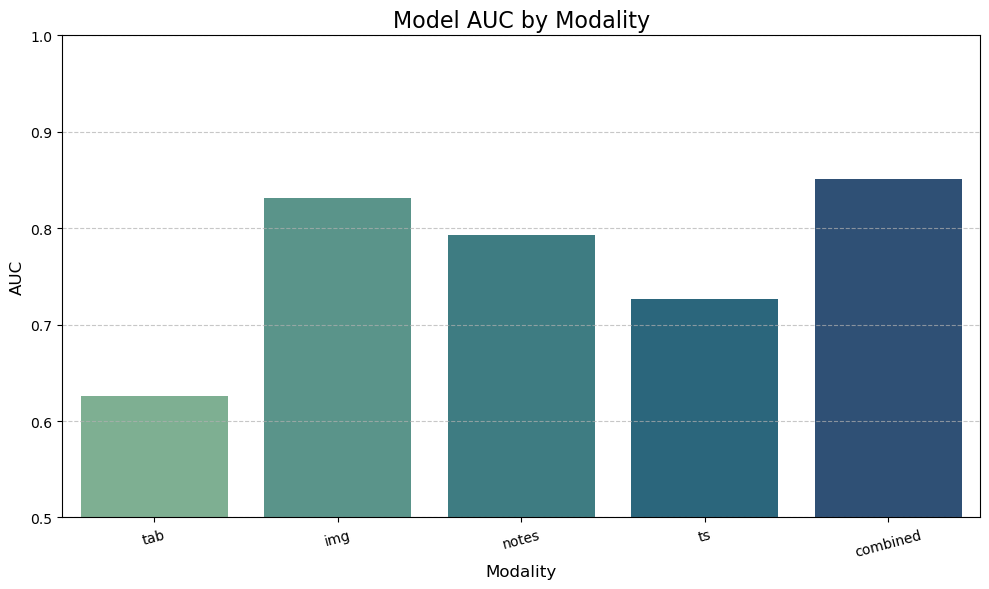

In [ ]:
plot_auc_by_modality(aucs)


We observe that multimodality improved our performance!

##🔑 Key Takeaways

Multimodal learning integrates different data types—structured data, clinical notes, imaging, and time series—to improve predictive performance in healthcare.

Domain-specific embeddings (e.g., ClinicalBERT for notes, DenseNet for images) capture rich modality-specific information that enhances downstream models.

Per-modality models provide insight into the standalone predictive power of each data source.

Fusion of modalities leads to better performance, highlighting the value of combining complementary information.

MIMIC-IV data enable realistic evaluation of multimodal models on complex ICU tasks like diagnosing pleural effusion.